# Deep Hedging & Pricing Simulator — walkthrough

European options priced three independent ways (analytic, autograd, pathwise Monte Carlo), a differential-ML pricer trained on prices **and** derivatives, and a deep-hedging policy under transaction costs. Everything runs on CPU in a couple of minutes.

In [1]:
import matplotlib.pyplot as plt
import torch

from dhps.bench.evaluate import greeks_curve
from dhps.bench.speed import mc_paths_for_error, payoff_std, time_fn
from dhps.datasets.european import make_european_dataset
from dhps.hedging.policy import DeepHedgeConfig, train_deep_hedge
from dhps.hedging.simulator import delta_positions, hedge_pnl, premium_bs
from dhps.pricing.aad import bs_greeks_ad
from dhps.pricing.black_scholes import bs_greeks
from dhps.pricing.pathwise_mc import pathwise_european_greeks
from dhps.simulators.gbm import simulate_gbm
from dhps.train.trainer import TrainConfig, train_model

## 1. Simulate the underlying

Exact log-space GBM under the risk-neutral measure.

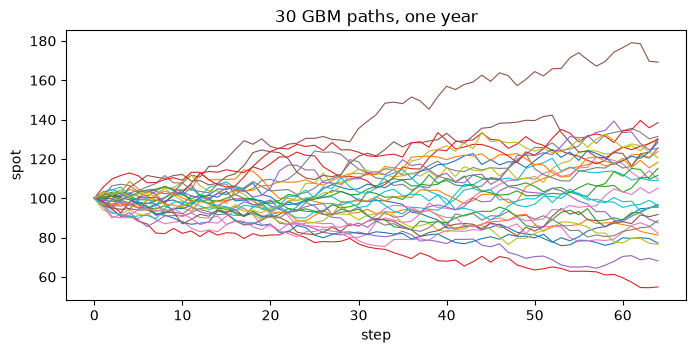

In [2]:
paths = simulate_gbm(n_paths=30, n_steps=64, s0=100.0, sigma=0.2,
                     t_maturity=1.0, antithetic=False, seed=3)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(paths.T, lw=0.8)
ax.set_title('30 GBM paths, one year')
ax.set_xlabel('step')
ax.set_ylabel('spot')
plt.show()

## 2. Three roads to the same Greek

Analytic formulas, autograd through the pricer, pathwise Monte Carlo — they must agree or something is broken.

In [3]:
s = torch.linspace(60.0, 150.0, 91, dtype=torch.float64)
ad = bs_greeks_ad(s, 100.0, 0.05, 0.01, 0.2, 1.0)
an = bs_greeks(s, 100.0, 0.05, 0.01, 0.2, 1.0)
pw = pathwise_european_greeks(n_paths=100_000, s0=100.0,
                              strike=100.0, r=0.05, q=0.01,
                              sigma=0.2, seed=11)
for g in ('delta', 'gamma', 'vega'):
    err = float((ad[g] - an[g]).abs().max())
    print(f'autograd vs analytic {g:6s}: max abs err {err:.2e}')
print(f'pathwise MC delta  {pw["delta"]:.4f} +- {2 * pw["delta_se"]:.4f}'
      f'   analytic {float(an["delta"][40]):.4f}')

autograd vs analytic delta : max abs err 4.44e-16
autograd vs analytic gamma : max abs err 3.47e-17
autograd vs analytic vega  : max abs err 5.68e-14
pathwise MC delta  0.6116 +- 0.0036   analytic 0.6118


## 3. Training data

Scrambled-Sobol coverage of (spot, moneyness, maturity, vol); labels are analytic prices and Greeks.

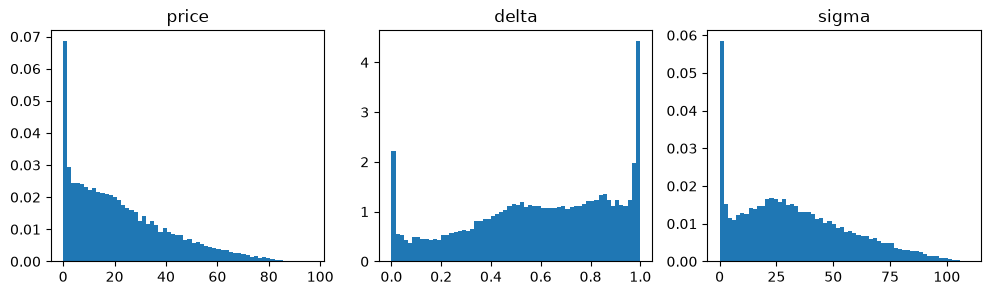

In [4]:
data = make_european_dataset(n_samples=20_000, seed=7)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, j, name in zip(axes, (0, 1, 3),
                       ('price', 'delta', 'sigma'), strict=True):
    ax.hist(data['y_train'][:, j], bins=60, density=True)
    ax.set_title(name)
plt.show()

## 4. Differential ML vs price-only baseline

Same network, same data. DML additionally fits the model's own input-gradients to the differential labels.

DML      delta MAE 0.0147
baseline delta MAE 0.0449


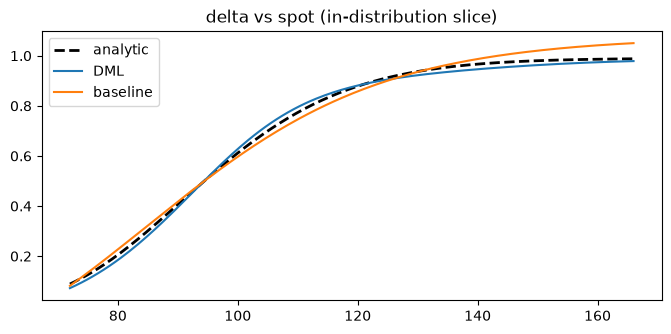

In [5]:
cfg = TrainConfig(n_samples=20_000, hidden=(64, 64, 64), epochs=300,
                  batch_size=8_192, seed=7)
dml = train_model(cfg, differential=True)
base = train_model(cfg, differential=False)
print(f'DML      delta MAE {dml.metrics["val_delta_mae"]:.4f}')
print(f'baseline delta MAE {base.metrics["val_delta_mae"]:.4f}')

spots = torch.linspace(72.0, 166.0, 200, dtype=torch.float64)
cd = greeks_curve(dml, spots, 100.0, 1.0, 0.2)
cb = greeks_curve(base, spots, 100.0, 1.0, 0.2)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(spots, cd['delta_true'], 'k--', label='analytic', lw=2)
ax.plot(spots, cd['delta'], label='DML', lw=1.5)
ax.plot(spots, cb['delta'], label='baseline', lw=1.5)
ax.set_title('delta vs spot (in-distribution slice)')
ax.legend()
plt.show()

## 5. Speed at matched error

Monte Carlo gets the path count its CLT standard error needs to match a 5-cent price target; the trained net prices the same option in one forward pass.

In [6]:
n_matched = mc_paths_for_error(payoff_std(), target_error=0.05)
xs = torch.randn(100_000, 4, dtype=torch.float64)
with torch.no_grad():
    t_batch = time_fn(lambda: dml.model(xs))
print(f'DML batched: {t_batch * 1e6 / 100_000:.2f} us/price')
print(f'matched Monte Carlo: {n_matched:,} paths per price')

DML batched: 0.89 us/price
matched Monte Carlo: 81,130 paths per price


## 6. Deep hedging under transaction costs

The policy network is trained by backpropagating entropic risk of terminal P&L through simulated trajectories, then compared with weekly delta hedging on shared eval paths.

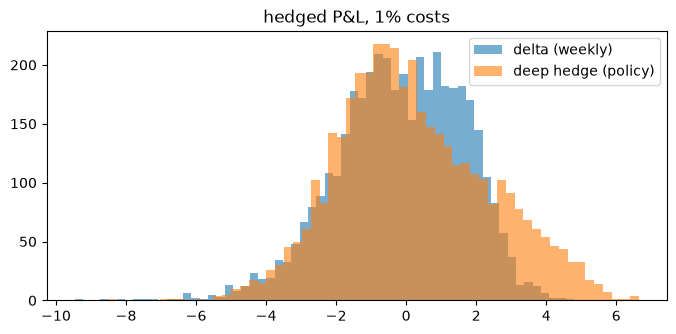

policy CVaR95 -3.87  mean +0.19  volume 1.7


In [7]:
hcfg = DeepHedgeConfig(n_paths=8_192, n_steps=26, cost_rate=0.01,
                       epochs=120, seed=7, eval_paths=4_096)
hres = train_deep_hedge(hcfg)

sim = dict(s0=hcfg.s0, r=hcfg.r, q=hcfg.q, sigma=hcfg.sigma,
           t_maturity=hcfg.t_maturity)
eval_paths = simulate_gbm(n_paths=hcfg.eval_paths,
                          n_steps=hcfg.n_steps, antithetic=True,
                          seed=hcfg.eval_seed, **sim)
prem = premium_bs(hcfg.s0, hcfg.strike, hcfg.r, hcfg.q, hcfg.sigma,
                  hcfg.t_maturity)
hdelta = delta_positions(eval_paths, hcfg.strike, hcfg.r, hcfg.q,
                         hcfg.sigma, hcfg.t_maturity)
pnl_delta = hedge_pnl(eval_paths, hcfg.strike, prem, hdelta,
                      hcfg.cost_rate)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(pnl_delta.numpy(), bins=60, alpha=0.6, label='delta (weekly)')
ax.hist(hres.eval_pnl.numpy(), bins=60, alpha=0.6,
        label='deep hedge (policy)')
ax.set_title('hedged P&L, 1% costs')
ax.legend()
plt.show()

print(f'policy CVaR95 {hres.metrics["cvar95"]:+.2f}'
      f'  mean {hres.metrics["mean"]:+.2f}'
      f'  volume {hres.metrics["traded_volume"]:.1f}')

## Where to go next

- `streamlit run app/dashboard.py` — the interactive version
- `python scripts/benchmark.py --device cuda` — full benchmark suite
- `pytest -q` — the statistical and regression gates